In [1]:
import numpy as np
from math import ceil

def gaussian_kernel(sigma, radius=None):
    if radius is None:
        radius = int(ceil(3*sigma))
    x = np.arange(-radius, radius+1)
    g = np.exp(-0.5*(x/sigma)**2)
    return g / g.sum()

def binomial_b3():
    return np.array([1,4,6,4,1],dtype=float)/16.0

def binomial_b4():
    return np.array([1,5,10,10,5,1],dtype=float)/32.0

def combine_and_normalize(base_kernel, sigma):
    g = gaussian_kernel(sigma)
    c = np.convolve(base_kernel, g, mode='full')
    c /= c.sum()
    return c


In [2]:
import sys
import numpy as np
#from scipy.signal import convolve
from scipy.ndimage import convolve1d

def starlet_transform_1d(signal, scales=5, bf = 'B3', verbose=False):
    """
    Calcula la transformada Starlet (undecimated wavelet transform à trous) 1D.
    
    Parámetros
    ----------
    signal : array_like
        Señal 1D de entrada (numpy array).
    scales : int
        Número de escalas (niveles de descomposición).
    bf : string
        Tipo de filtro base para definir la wavelet padre 
        (B1, B2, B3, B4, B5, Gaussian, Barlett, Meyer, bior1.3, bior2.2, bior3.3, B3-Gauss0.5, B3-Gauss1.0, B4-Gauss0.5, B4-Gauss1.0)
    verbose : bool
        Si True, muestra información de depuración.

    Retorna
    -------
    coeffs : list of np.ndarray
        Lista con los coeficientes [w1, w2, ..., wJ, cJ].
        - wj: detalle en la escala j
        - cJ: aproximación final (escala más grande)
    """

    # Filtro base (Bx)
    if bf == 'B1':
        h = np.array([1, 1], dtype=float) / 2.0      # B1-box
    elif bf == 'B2':
        h = np.array([1, 2, 1], dtype=float) / 4.0      # B2-triangular
    elif bf == 'B3':
        h = np.array([1, 4, 6, 4, 1], dtype=float) / 16.0      # B3-spline
    elif bf == 'B4': 
        h = np.array([1, 5, 10, 10, 5, 1], dtype=float) / 32.0      # B4
    elif bf == 'B5': 
        h = np.array([1, 6, 15, 20, 15, 6, 1], dtype=float) / 64.0      # B5

    # Filtro base (Gaussiana truncada sigma = 2)
    elif bf == 'Gaussian': 
        h = np.array([1,12,66,220,495,792,924,792,495,220,66,12,1], dtype=float) / 1024.0
    # Filtro base (Bartlett)
    elif bf == 'Bartlett': 
        h = np.array([1,2,2,2,1], dtype=float) / 8.0

    # B3 y B4 combinados con Gaussianas
    elif bf == 'B3-Gauss0.5':
        h = combine_and_normalize(binomial_b3(), 0.5)
    elif bf == 'B3-Gauss1.0':
        h  = combine_and_normalize(binomial_b3(), 1.0)
    elif bf == 'B4-Gauss0.5':
        h = combine_and_normalize(binomial_b4(), 0.5)
    elif bf == 'B4-Gauss1.0':
        h  = combine_and_normalize(binomial_b4(), 1.0)
    
    # Biortogonales
    elif bf == 'bior1.3':
        h = np.array([0.0, 0.0378, -0.0238, -0.1106, 0.3774, 0.8527, 0.3774, -0.1106, -0.0238, 0.0378], dtype=float) 
    elif bf == 'bior2.2': 
        h = np.array([0.0, 0.1768, 0.3536, 0.1768, 0.0], dtype=float) 
    elif bf == 'bior3.3': 
        h = np.array([0.0, -0.0645, 0.0407, 0.4181, 0.7885, 0.4181, 0.0407, -0.0645, 0.0], dtype=float)
        
    # Meyer
    elif bf == 'Meyer':
        h = np.array([3,12,30,50,63,50,30,12,3], dtype=float) / 256.0
    else:
        print('Opción para filtro base no contemplada')
        sys.exit()
    
    c = signal.astype(float)
    coeffs = []

    for j in range(scales):
        # Dilatar el filtro insertando ceros ("à trous" = con agujeros)
        step = 2 ** j
        h_dilated = np.zeros((len(h) - 1) * step + 1)
        h_dilated[::step] = h

        # Convolución con padding simétrico
        c_smooth = convolve1d(c, h_dilated, mode = 'reflect')#, method='auto')
        w = c - c_smooth

        coeffs.append(w)
        c = c_smooth

        if verbose:
            print(f"Escala {j+1}: longitud filtro={len(h_dilated)}")

    # Añadimos la aproximación final
    coeffs.append(c)
    return coeffs


def starlet_reconstruction_1d(coeffs):
    """
    Reconstruye la señal original a partir de los coeficientes Starlet 1D.

    Parámetros
    ----------
    coeffs : list of np.ndarray
        Lista con los coeficientes [w1, ..., wJ, cJ]

    Retorna
    -------
    signal_rec : np.ndarray
        Señal reconstruida.
    """
    w_coeffs = coeffs[:-1]
    c_final = coeffs[-1]
    return c_final + np.sum(w_coeffs, axis=0)


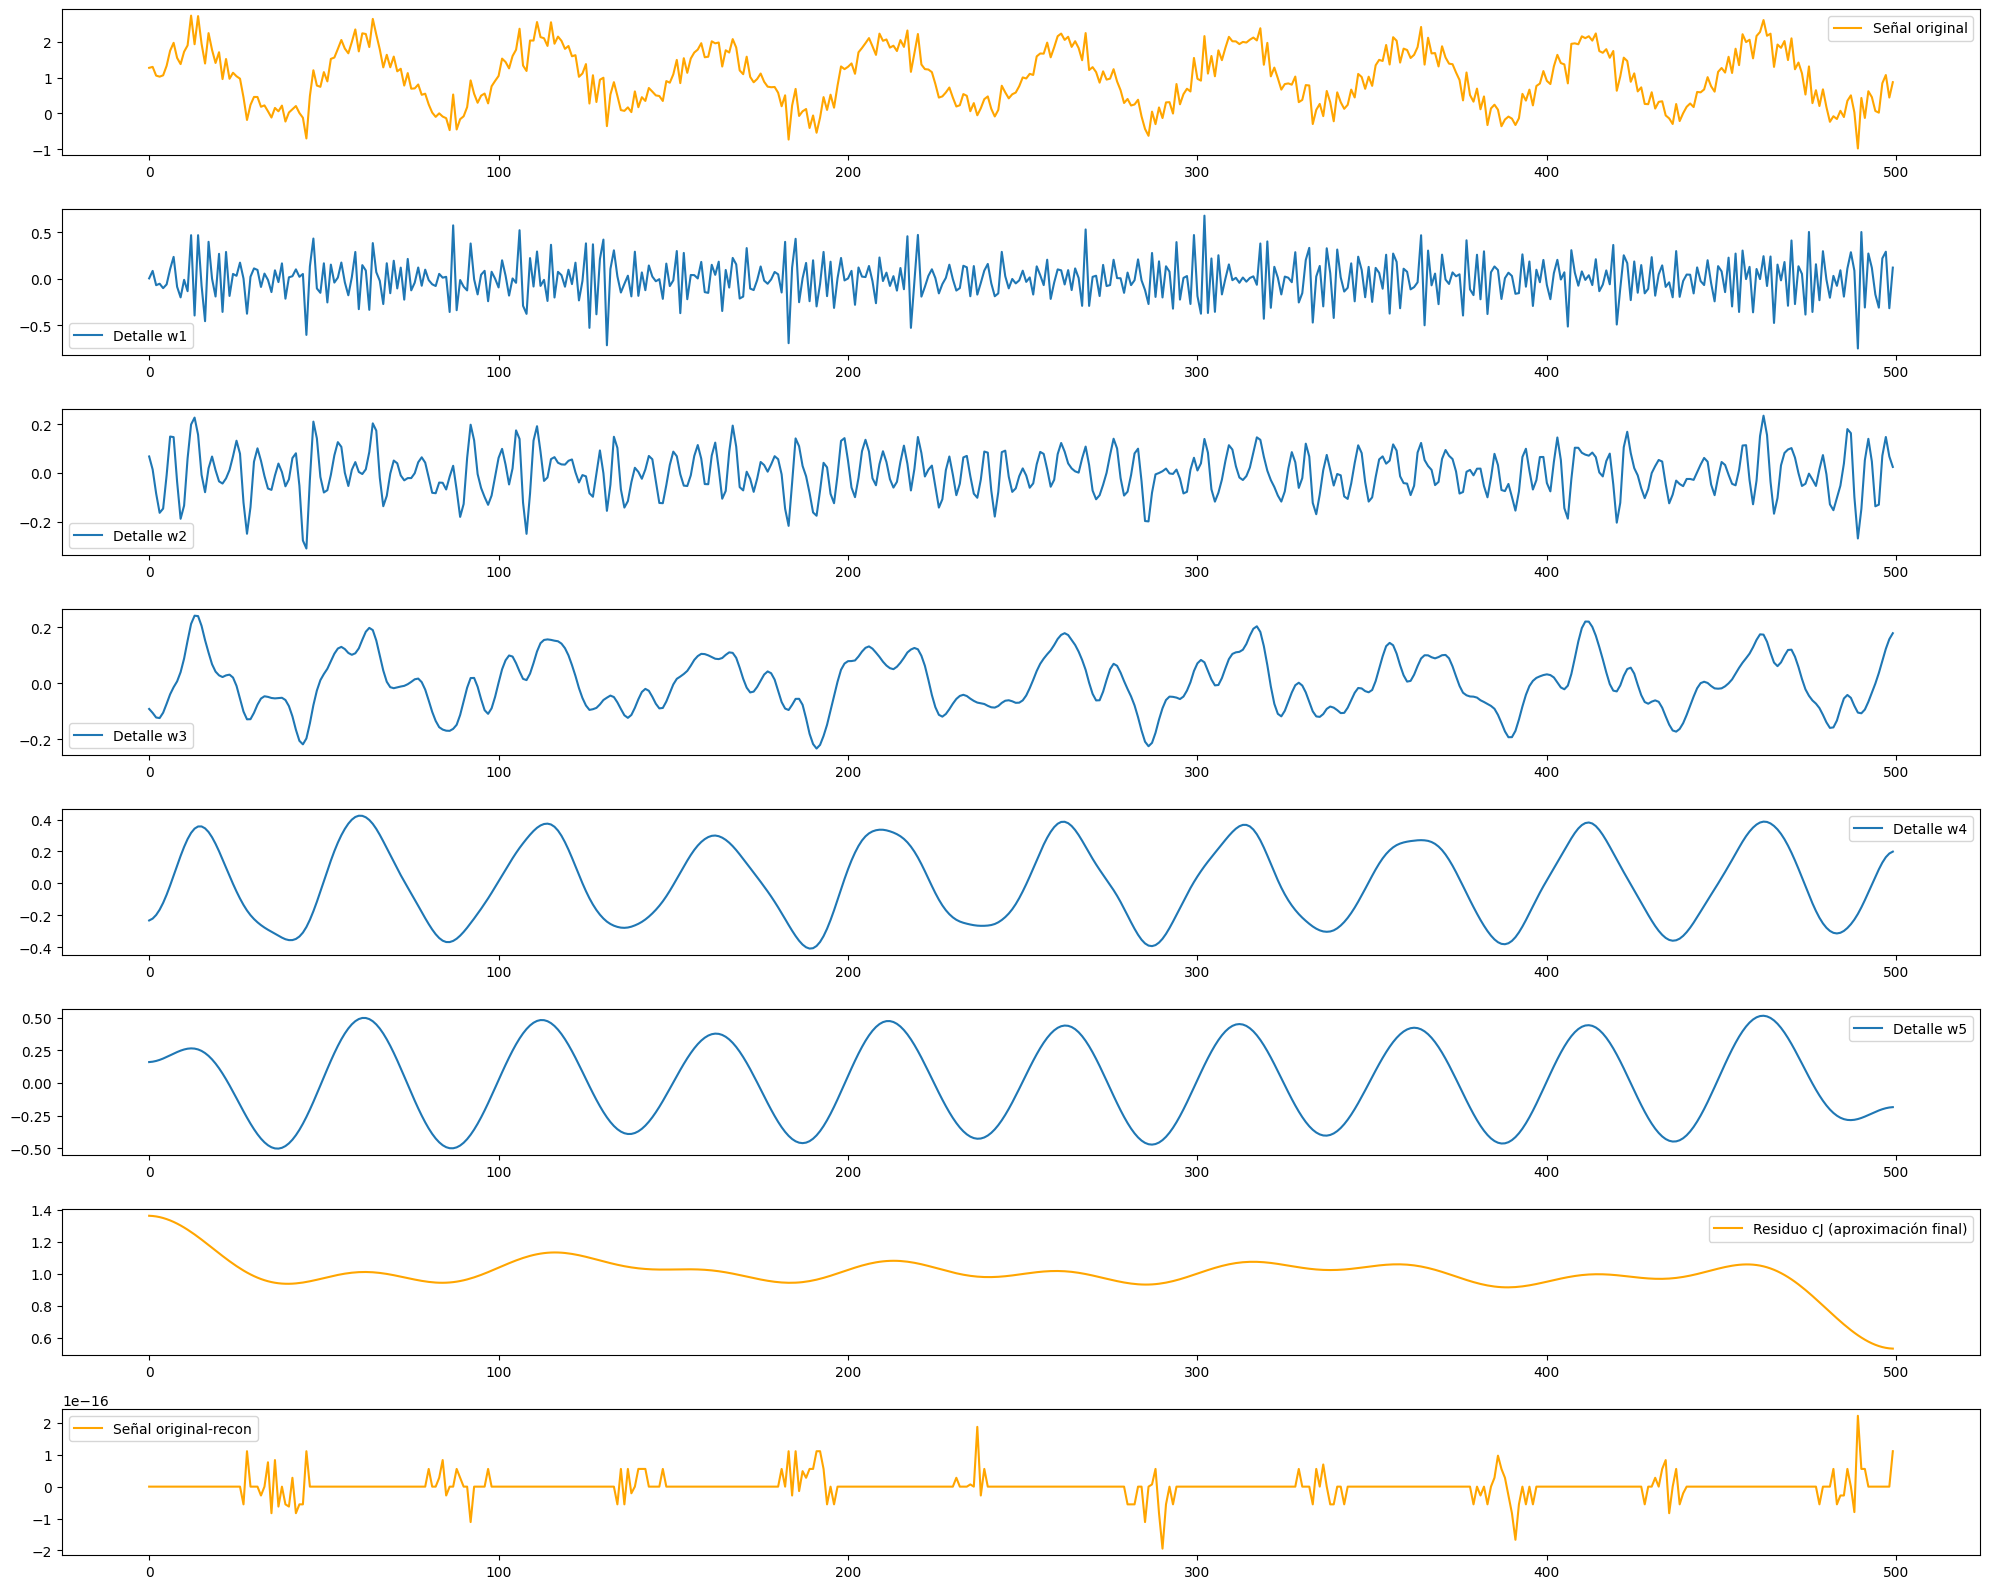

In [3]:
import matplotlib.pyplot as plt

# Señal ejemplo
x = np.linspace(0, 10, 500)
signal = 1 + np.sin(2*np.pi*x) + 0.3*np.random.randn(len(x))
scales = 5
# Transformada Starlet
coeffs = starlet_transform_1d(signal, scales = scales, bf = 'B3', verbose = False)

# Reconstrucción
signal_rec = starlet_reconstruction_1d(coeffs)

# Visualización
plt.figure(figsize=(20, 16))
plt.subplot(scales+3, 1, 1)
plt.plot(signal, label='Señal original', color='orange')
plt.legend()

for i, w in enumerate(coeffs[:-1], 1):
    plt.subplot(scales+3, 1, i+1)
    plt.plot(w, label=f'Detalle w{i}')
    plt.legend()

plt.subplot(scales+3, 1, scales+2)
plt.plot(coeffs[-1], label='Residuo cJ (aproximación final)', color='orange')
plt.legend()

plt.subplot(scales+3, 1, scales+3)
plt.plot(signal-signal_rec, label='Señal original-recon', color='orange')
plt.legend()

plt.tight_layout()
plt.show()


